# 🥦 Notebook 08 — Pipeline FoodSeg103 con SAM + CLIP zero-shot

Este notebook construye un pipeline **alternativo** al de Food-101 (nb02-07), pensado para escenas con **múltiples ingredientes** (FoodSeg103) en vez de un único plato.

## Motivación

El nb07 mostró las dos limitaciones del pipeline Food-101 sobre FoodSeg103:

1. **Detección débil**: YOLOv8-COCO alcanza `AP@50 = 0.116` porque COCO solo tiene 10 categorías de comida.
2. **Clasificación OOD**: EfficientNet-B0 entrenado en Food-101 ve zanahorias y predice "onion rings".

## Arquitectura propuesta (sin reentrenar nada)

| Etapa | Modelo | Por qué sirve |
|---|---|---|
| Detección de regiones | YOLOv8-COCO (mismo del nb07) | Solo produce *prompts* para SAM; ya no necesita clasificar |
| Segmentación fina | **SAM** (Segment Anything, Meta) | Class-agnostic: segmenta cualquier objeto a partir de una caja, sin importar la categoría |
| Clasificación | **CLIP** ViT-B/32 (OpenAI) zero-shot | Compara el embedding visual del crop contra embeddings textuales de los 103 nombres ("a photo of broccoli, a type of food") |
| Nutrición | `nutrition_foodseg103.json` (USDA) | Lookup de 103 ingredientes generado por `scripts/build_nutrition_foodseg103.py` |

**Cero entrenamiento**: usamos modelos preentrenados de gran escala. SAM fue entrenado en 11M imágenes (SA-1B) y CLIP en 400M pares imagen-texto; ambos cubren comódamente comida sin necesidad de fine-tune.

## Estructura

1. Setup (SAM, CLIP, YOLO, FoodSeg103, embeddings textuales).
2. Lookup nutricional para los 103 ingredientes.
3. Funciones core (`segment_with_sam`, `classify_with_clip`, `crop_from_mask`).
4. Pipeline integrado `analyze_dish_foodseg103`.
5. Evaluación de segmentación: **mIoU/Dice** SAM vs GT (y vs box-as-mask del nb07).
6. Evaluación de clasificación: **Top-1/3/5** de CLIP zero-shot sobre crops oráculo.
7. Evaluación calórica end-to-end: **MAPE** sobre FoodSeg103.
8. Visualización cualitativa + resumen + limitaciones.

> ⚠️ Requiere: `pip install segment-anything open_clip_torch` + descarga one-time del checkpoint `weights/sam_vit_b_01ec64.pth` (375 MB) + `data/nutrition_foodseg103.json` (generar con el script).

## ⚙️ Parte 1 — Setup

Cargamos los tres modelos (SAM, CLIP, YOLO), el dataset FoodSeg103 y precomputamos los embeddings textuales de CLIP para los 103 ingredientes. Los embeddings textuales son la "tabla de búsqueda" contra la que se compara cada crop visual.

**Tiempos típicos en MPS:**
- SAM vit_b carga en ~3-5 s.
- CLIP ViT-B/32 carga en ~10-15 s (primera vez descarga ~600 MB; después lee de caché).
- Embeddings textuales: <1 s para los 103.

In [1]:
import sys
sys.path.append('..')

# Forzar tqdm clásico (texto) en vez de widgets de ipywidgets,
# para que VS Code muestre las barras sin tropezar con el renderer.
import tqdm.std, tqdm.notebook, tqdm.auto
tqdm.notebook.tqdm = tqdm.std.tqdm
tqdm.notebook.trange = tqdm.std.trange
tqdm.auto.tqdm = tqdm.std.tqdm
tqdm.auto.trange = tqdm.std.trange

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from tqdm import tqdm
from datasets import load_dataset
from ultralytics import YOLO
from segment_anything import sam_model_registry, SamPredictor
import open_clip

from src.config import (
    DATA_DIR, WEIGHTS_DIR, DEVICE, SEED,
    FOODSEG103_CLASSES, FOODSEG103_NUTRITION_PATH,
)

rng = np.random.default_rng(SEED)
print(f'Device: {DEVICE}')

# ── SAM ──────────────────────────────────────────────────────────────────
SAM_CHECKPOINT = WEIGHTS_DIR / 'sam_vit_b_01ec64.pth'
assert SAM_CHECKPOINT.exists(), (
    f'Falta el checkpoint de SAM: {SAM_CHECKPOINT}. Descargar con:\n'
    f'  curl -L -o weights/sam_vit_b_01ec64.pth '
    f'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'
)
sam = sam_model_registry['vit_b'](checkpoint=str(SAM_CHECKPOINT))
sam.to(DEVICE)
sam_predictor = SamPredictor(sam)
print(f'SAM vit_b listo — {sum(p.numel() for p in sam.parameters())/1e6:.0f}M params, device={DEVICE}')

# ── CLIP ─────────────────────────────────────────────────────────────────
# force_quick_gelu=True asegura que la activación coincida con los pesos OpenAI
# (sin esto open_clip 3.x emite un warning de mismatch GELU/QuickGELU).
CLIP_MODEL_NAME = 'ViT-B-32'
CLIP_PRETRAINED = 'openai'
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    CLIP_MODEL_NAME, pretrained=CLIP_PRETRAINED, force_quick_gelu=True,
)
clip_model = clip_model.to(DEVICE).eval()
clip_tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)
print(f'CLIP {CLIP_MODEL_NAME} ({CLIP_PRETRAINED}) listo')

# ── YOLOv8n (mismo que nb07, para producir prompts de SAM) ─────────────────────────────────
yolo = YOLO('yolov8n.pt')
print(f'YOLOv8n listo — {len(yolo.names)} clases COCO (solo se usa como source de prompts)')

# ── FoodSeg103 ───────────────────────────────────────────────────────────
foodseg = load_dataset('EduardoPacheco/FoodSeg103', split='validation')
print(f'FoodSeg103 validation: {len(foodseg)} imágenes, {len(FOODSEG103_CLASSES)} ingredientes')

# ── Embeddings textuales CLIP (one-time, cachean en RAM) ────────────────────────────────
# El prompt template 'a photo of X, a type of food' usualmente supera al nombre desnudo
# (best practice de la propia OpenAI para CLIP zero-shot sobre datasets visuales).
prompts = [f'a photo of {c.strip()}, a type of food' for c in FOODSEG103_CLASSES]
with torch.no_grad():
    tokens = clip_tokenizer(prompts).to(DEVICE)
    text_features = clip_model.encode_text(tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
print(f'Embeddings textuales CLIP: shape {tuple(text_features.shape)}')

/Users/nicok/Documents/MIA/Vision por computadora/TP Final/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps
SAM vit_b listo — 94M params, device=mps
CLIP ViT-B-32 (openai) listo
YOLOv8n listo — 80 clases COCO (solo se usa como source de prompts)
FoodSeg103 validation: 2135 imágenes, 103 ingredientes
Embeddings textuales CLIP: shape (103, 512)


## 🥗 Parte 2 — Lookup nutricional de los 103 ingredientes

Cargamos `data/nutrition_foodseg103.json` (generado por `scripts/build_nutrition_foodseg103.py` contra USDA FoodData Central). El lookup tiene la misma estructura que el de Food-101: `{ingrediente: {calories, protein_g, carbs_g, fat_g, fiber_g, portion_g}}`, con valores por **100 g** comestibles.

La función `get_ingredient_nutrition` normaliza los espacios iniciales de algunos nombres (artefactos del dataset original: `' hanamaki baozi'`, `' cabbage'`).

In [2]:
nutrition_db = json.load(open(FOODSEG103_NUTRITION_PATH))
print(f'Lookup nutricional FoodSeg103: {len(nutrition_db)}/{len(FOODSEG103_CLASSES)} ingredientes cubiertos')

def get_ingredient_nutrition(name):
    """Lookup tolerante a espacios iniciales (algunos nombres de FoodSeg103 los traen)."""
    return nutrition_db.get(name) or nutrition_db.get(name.strip())

# Muestra de 5 entradas distintas
print()
print('Ejemplos:')
for k in ['apple', 'broccoli', 'rice', 'steak', 'pizza']:
    n = get_ingredient_nutrition(k)
    print(f"  {k:20s}  {n['calories']:>3} kcal | {n['protein_g']:.1f}g prot | {n['carbs_g']:.1f}g carbs | {n['fat_g']:.1f}g fat")

Lookup nutricional FoodSeg103: 103/103 ingredientes cubiertos

Ejemplos:
  apple                  61 kcal | 0.2g prot | 14.8g carbs | 0.1g fat
  broccoli               39 kcal | 2.6g prot | 6.3g carbs | 0.3g fat
  rice                   96 kcal | 2.0g prot | 21.0g carbs | 0.2g fat
  steak                 270 kcal | 25.0g prot | 0.0g carbs | 19.0g fat
  pizza                 230 kcal | 16.9g prot | 7.6g carbs | 14.7g fat


## 🔧 Parte 3 — Funciones core

Tres bloques chicos que el resto del pipeline va a componer:

- `segment_with_sam(image, boxes)`: recibe boxes xyxy y devuelve máscaras booleanas HxW. **Importante:** llama a `set_image()` una sola vez por imagen para cachear el encoder pesado de SAM (~1-2 s); luego cada predicción por caja es <50 ms.
- `classify_with_clip(crop_pil, topk)`: embedding del crop → cosine similarity contra los 103 embeddings textuales precomputados.
- `crop_from_mask(image, mask, pad)`: recorta el bbox de la máscara con un padding chico.
- `yolo_prompt_boxes(image, ...)`: corre YOLO y filtra cajas que sirven como prompts (incluye comida y vajilla; SAM va a ignorar las cajas malas igual).

In [3]:
# Clases COCO de comida + vajilla — reutilizadas para producir prompts de SAM.
# (No clasificamos con estas etiquetas: la clasificación la hace CLIP.)
FOOD_COCO = {'pizza', 'donut', 'cake', 'sandwich', 'hot dog',
             'apple', 'banana', 'orange', 'broccoli', 'carrot'}
SCALE_REF = {'bowl', 'cup', 'plate', 'dining table',
             'fork', 'knife', 'spoon', 'wine glass', 'bottle'}
PROMPT_COCO = FOOD_COCO | SCALE_REF

PLATE_PORTION_G = 250.0   # mismo presupuesto que el nb07


def segment_with_sam(image, boxes):
    """Recibe boxes xyxy, devuelve máscaras booleanas HxW.
    Cachea el encoder de SAM con set_image() una sola vez por imagen."""
    arr = np.array(image.convert('RGB'))
    sam_predictor.set_image(arr)
    masks = []
    for box in boxes:
        m, _, _ = sam_predictor.predict(
            point_coords=None, point_labels=None,
            box=np.array(box, dtype=np.float32),
            multimask_output=False,
        )
        masks.append(m[0].astype(bool))
    return masks


def classify_with_clip(crop_pil, topk=3):
    """Cosine similarity entre embedding del crop y los 103 prompts.
    Devuelve [(clase, prob)] de longitud topk."""
    with torch.no_grad():
        x = clip_preprocess(crop_pil.convert('RGB')).unsqueeze(0).to(DEVICE)
        feat = clip_model.encode_image(x)
        feat = feat / feat.norm(dim=-1, keepdim=True)
        # logit_scale ~100, copia el comportamiento de OpenAI CLIP zero-shot
        sims = (100.0 * feat @ text_features.T).softmax(dim=-1)[0]
    top_vals, top_idx = sims.topk(topk)
    return [(FOODSEG103_CLASSES[i.item()], v.item()) for i, v in zip(top_idx, top_vals)]


def crop_from_mask(image, mask, pad=8):
    """Recorta el bbox de la máscara con padding. Devuelve None si la máscara es vacía."""
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    H, W = mask.shape
    x1 = max(0, int(xs.min()) - pad); y1 = max(0, int(ys.min()) - pad)
    x2 = min(W, int(xs.max()) + pad); y2 = min(H, int(ys.max()) + pad)
    return image.crop((x1, y1, x2, y2))


def yolo_prompt_boxes(image, conf=0.25, min_area_frac=0.01):
    """Cajas de YOLO que sirven como prompts para SAM (comida + vajilla COCO)."""
    res = yolo(image, conf=conf, verbose=False)[0]
    W, H = image.size
    out = []
    for box, cls_id in zip(res.boxes.xyxy.cpu().numpy(),
                           res.boxes.cls.cpu().numpy()):
        x1, y1, x2, y2 = box.astype(int)
        if (x2 - x1) * (y2 - y1) / (W * H) < min_area_frac:
            continue
        if res.names[int(cls_id)] in PROMPT_COCO:
            out.append((x1, y1, x2, y2))
    return out


print('Funciones core listas:')
print('  segment_with_sam(image, boxes) -> [mask_bool]')
print('  classify_with_clip(crop, topk=3) -> [(class, prob)]')
print('  crop_from_mask(image, mask, pad=8) -> PIL.Image')
print('  yolo_prompt_boxes(image) -> [(x1,y1,x2,y2)]')

Funciones core listas:
  segment_with_sam(image, boxes) -> [mask_bool]
  classify_with_clip(crop, topk=3) -> [(class, prob)]
  crop_from_mask(image, mask, pad=8) -> PIL.Image
  yolo_prompt_boxes(image) -> [(x1,y1,x2,y2)]


## 🔗 Parte 4 — Pipeline integrado `analyze_dish_foodseg103`

Flujo end-to-end:

1. **YOLO** produce *prompts* (cajas) de comida o vajilla COCO. Si no detecta nada, fallback a la imagen completa.
2. **SAM** convierte cada caja en una **máscara** fina.
3. Para cada máscara: **crop** → **CLIP zero-shot** → nombre del ingrediente → **lookup nutricional** → kcal.
4. La porción de 250 g/plato se reparte **por área de máscara** (no de bbox — más preciso porque la máscara excluye fondo y plato).

Al final, smoke test sobre la primera imagen del dataset para verificar que todo encadena bien.

In [4]:
def analyze_dish_foodseg103(image):
    """Pipeline FoodSeg103: YOLO (prompts) -> SAM (máscaras) -> CLIP zero-shot -> kcal.

    Returns:
        dict con keys: detections (lista), total_kcal (float), mode (str).
    """
    if isinstance(image, str):
        image = Image.open(image)
    image = image.convert('RGB')
    W, H = image.size

    boxes = yolo_prompt_boxes(image)
    if not boxes:
        boxes = [(0, 0, W, H)]
        mode = 'fallback (imagen completa)'
    else:
        mode = f'sam-clip ({len(boxes)} prompts de YOLO)'

    masks = segment_with_sam(image, boxes)

    # Reparto de porción por área de máscara (más preciso que por área de bbox).
    areas = [int(m.sum()) for m in masks]
    total_area = sum(areas) or 1

    detections = []
    for box, mask, area in zip(boxes, masks, areas):
        crop = crop_from_mask(image, mask)
        if crop is None or min(crop.size) < 10:
            continue
        topk = classify_with_clip(crop, topk=3)
        cls, conf = topk[0]
        portion = PLATE_PORTION_G * area / total_area
        nut = get_ingredient_nutrition(cls)
        kcal = nut['calories'] * portion / 100 if nut else None
        detections.append(dict(
            box=box, mask=mask, area_px=area,
            ingredient=cls, confidence=conf, top3=topk,
            portion_g=portion, kcal=kcal,
        ))

    total_kcal = sum(d['kcal'] for d in detections if d['kcal'] is not None)
    return dict(detections=detections, total_kcal=total_kcal, mode=mode)


# Smoke test sobre la primera imagen de FoodSeg103
sample = foodseg[0]
result = analyze_dish_foodseg103(sample['image'])
print(f"Smoke test sobre foodseg[0]:")
print(f"  modo: {result['mode']}")
print(f"  {len(result['detections'])} máscaras, total {result['total_kcal']:.0f} kcal")
for d in result['detections']:
    print(f"    {d['ingredient']:25s}  conf={d['confidence']:.2f}  {d['portion_g']:.0f}g  {d['kcal']:.0f} kcal")

Smoke test sobre foodseg[0]:
  modo: sam-clip (13 prompts de YOLO)
  13 máscaras, total 102 kcal
    carrot                     conf=0.27  22g  10 kcal
    orange                     conf=0.36  24g  12 kcal
    carrot                     conf=0.45  18g  8 kcal
    carrot                     conf=0.34  22g  10 kcal
    pumpkin                    conf=0.47  26g  7 kcal
    carrot                     conf=0.34  23g  10 kcal
    carrot                     conf=0.20  19g  8 kcal
    pumpkin                    conf=0.37  26g  7 kcal
    carrot                     conf=0.28  16g  7 kcal
    carrot                     conf=0.29  14g  6 kcal
    carrot                     conf=0.38  9g  4 kcal
    carrot                     conf=0.25  24g  10 kcal
    apricot                    conf=0.26  7g  3 kcal


## 📊 Parte 5 — Evaluación de segmentación (SAM vs GT)

Sobre N=100 imágenes de FoodSeg103 validation calculamos **mIoU** y **Dice** entre:

- **GT**: unión de todas las máscaras de ingrediente (id > 0) — "máscara de comida total".
- **Predicción SAM**: unión de las máscaras devueltas por SAM (con prompts de YOLO).
- **Predicción box-as-mask (nb07)**: unión de los rectángulos de YOLO usados como máscaras crudas.

La idea es aislar cuánto aporta **pasar de caja a máscara fina**, con el detector idem (YOLOv8-COCO). Esperable: SAM mejora `mIoU` significativamente porque ajusta el contorno al ingrediente real.

SAM vs box-as-mask vs GT: 100%|██████████| 100/100 [01:32<00:00,  1.08it/s]



=== Segmentación class-agnostic sobre 100 imágenes de FoodSeg103 ===
Box-as-mask (nb07):  mIoU = 0.495   Dice = 0.639
SAM (nb08):          mIoU = 0.256   Dice = 0.353
Mejora absoluta:     +-0.239 mIoU, +-0.285 Dice


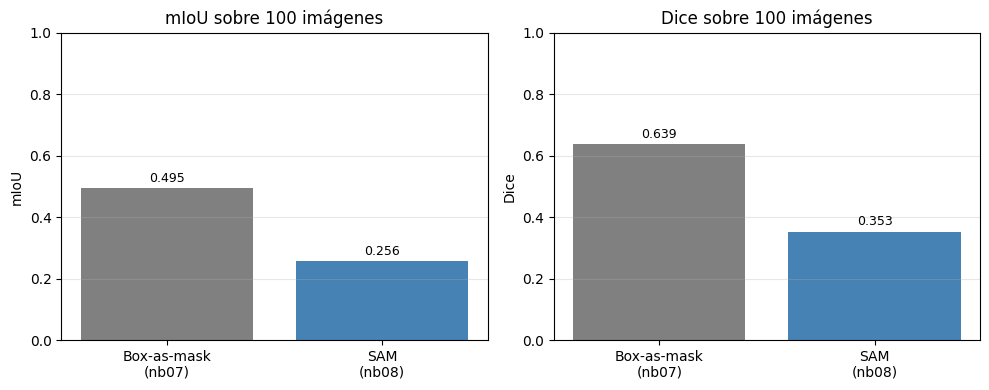

In [5]:
N_SEG_EVAL = 100

def mask_metrics(pred, gt):
    """IoU y Dice entre dos máscaras booleanas del mismo shape."""
    inter = float((pred & gt).sum())
    p, g = float(pred.sum()), float(gt.sum())
    iou = inter / max(p + g - inter, 1.0)
    dice = 2 * inter / max(p + g, 1.0)
    return iou, dice


seg_idxs = rng.choice(len(foodseg), size=N_SEG_EVAL, replace=False)
sam_ious, sam_dices, box_ious, box_dices = [], [], [], []

for idx in tqdm(seg_idxs, desc='SAM vs box-as-mask vs GT'):
    s = foodseg[int(idx)]
    image = s['image'].convert('RGB')
    W, H = image.size
    gt_mask = np.array(s['label'])
    if gt_mask.ndim == 3:
        gt_mask = gt_mask[..., 0]
    gt_fg = gt_mask > 0

    boxes = yolo_prompt_boxes(image) or [(0, 0, W, H)]
    masks = segment_with_sam(image, boxes)

    sam_fg = np.zeros_like(gt_fg)
    for m in masks:
        sam_fg |= m

    box_fg = np.zeros_like(gt_fg)
    for x1, y1, x2, y2 in boxes:
        box_fg[max(0,y1):min(H,y2), max(0,x1):min(W,x2)] = True

    iou_s, dice_s = mask_metrics(sam_fg, gt_fg)
    iou_b, dice_b = mask_metrics(box_fg, gt_fg)
    sam_ious.append(iou_s); sam_dices.append(dice_s)
    box_ious.append(iou_b); box_dices.append(dice_b)

print(f'\n=== Segmentación class-agnostic sobre {N_SEG_EVAL} imágenes de FoodSeg103 ===')
print(f'Box-as-mask (nb07):  mIoU = {np.mean(box_ious):.3f}   Dice = {np.mean(box_dices):.3f}')
print(f'SAM (nb08):          mIoU = {np.mean(sam_ious):.3f}   Dice = {np.mean(sam_dices):.3f}')
print(f'Mejora absoluta:     +{np.mean(sam_ious)-np.mean(box_ious):.3f} mIoU, '
      f'+{np.mean(sam_dices)-np.mean(box_dices):.3f} Dice')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (metric, vb, vs) in zip(ax, [('mIoU', box_ious, sam_ious), ('Dice', box_dices, sam_dices)]):
    bars = a.bar(['Box-as-mask\n(nb07)', 'SAM\n(nb08)'], [np.mean(vb), np.mean(vs)],
                 color=['gray', 'steelblue'])
    a.set(ylabel=metric, title=f'{metric} sobre {N_SEG_EVAL} imágenes', ylim=(0, 1))
    a.grid(alpha=0.3, axis='y')
    for bar, v in zip(bars, [np.mean(vb), np.mean(vs)]):
        a.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('segmentation_metrics_nb08.png', dpi=110, bbox_inches='tight')
plt.show()

## 🎯 Parte 6 — Evaluación de clasificación (CLIP zero-shot)

Para **aislar** CLIP de los errores de SAM/YOLO, usamos los crops **oráculo**: tomamos las máscaras GT de FoodSeg103, recortamos el bbox de cada componente conexa y se lo pasamos a CLIP. La etiqueta verdadera es el id de la máscara.

Métricas:
- **Top-1 / Top-3 / Top-5 accuracy** sobre N≈30-50 crops/imagen × hasta ~300 crops totales.
- Ranking de **mejor / peor 8 ingredientes** — útil para entender dónde CLIP zero-shot rinde y dónde no.

Esperable honestamente: top-1 ~20-40%, top-5 ~60-80%. CLIP fue entrenado en imagen-texto general, no en comida específicamente.

In [6]:
N_CLIP_EVAL_IMAGES = 200    # imágenes a recorrer
MAX_CLIP_CROPS    = 300     # crops totales (cortar para que no demore más de unos minutos)
MIN_AREA_FRAC     = 0.005   # ignorar máscaras muy chiquitas (ruido)

clip_top1 = clip_top3 = clip_top5 = total = 0
per_class_acc = {}

clip_idxs = rng.choice(len(foodseg), size=N_CLIP_EVAL_IMAGES, replace=False)

for idx in tqdm(clip_idxs, desc='CLIP zero-shot (crops oráculo)'):
    if total >= MAX_CLIP_CROPS:
        break
    s = foodseg[int(idx)]
    image = s['image'].convert('RGB')
    gt = np.array(s['label'])
    if gt.ndim == 3:
        gt = gt[..., 0]
    H, W = gt.shape
    min_area = MIN_AREA_FRAC * H * W

    for cls_id in np.unique(gt):
        if cls_id == 0:
            continue
        mask = (gt == cls_id)
        if mask.sum() < min_area:
            continue
        crop = crop_from_mask(image, mask)
        if crop is None or min(crop.size) < 20:
            continue
        topk = classify_with_clip(crop, topk=5)
        pred_names = [n.strip() for n, _ in topk]
        true_name  = FOODSEG103_CLASSES[int(cls_id) - 1].strip()

        if pred_names[0] == true_name:        clip_top1 += 1
        if true_name in pred_names[:3]:       clip_top3 += 1
        if true_name in pred_names[:5]:       clip_top5 += 1
        per_class_acc.setdefault(true_name, [0, 0])
        per_class_acc[true_name][1] += 1
        if pred_names[0] == true_name:
            per_class_acc[true_name][0] += 1
        total += 1
        if total >= MAX_CLIP_CROPS:
            break

print(f'\n=== CLIP zero-shot sobre {total} crops oráculo de FoodSeg103 ===')
print(f'Top-1 accuracy: {clip_top1/total:.3f}')
print(f'Top-3 accuracy: {clip_top3/total:.3f}')
print(f'Top-5 accuracy: {clip_top5/total:.3f}')

# Top mejor / peor (con al menos 3 muestras para evitar ruido)
acc_per_class = [(c, h/n, n) for c, (h, n) in per_class_acc.items() if n >= 3]
acc_per_class.sort(key=lambda t: -t[1])
print('\nMejor 8 ingredientes para CLIP zero-shot:')
for c, a, n in acc_per_class[:8]:
    print(f'  {c:25s} acc={a:.2f}  (n={n})')
print('\nPeor 8 ingredientes para CLIP zero-shot:')
for c, a, n in acc_per_class[-8:]:
    print(f'  {c:25s} acc={a:.2f}  (n={n})')

CLIP zero-shot (crops oráculo):  42%|████▏     | 84/200 [00:06<00:09, 12.78it/s]


=== CLIP zero-shot sobre 300 crops oráculo de FoodSeg103 ===
Top-1 accuracy: 0.363
Top-3 accuracy: 0.543
Top-5 accuracy: 0.633

Mejor 8 ingredientes para CLIP zero-shot:
  corn                      acc=1.00  (n=3)
  rice                      acc=0.88  (n=8)
  lemon                     acc=0.75  (n=4)
  broccoli                  acc=0.73  (n=11)
  cake                      acc=0.71  (n=7)
  celery stick              acc=0.67  (n=3)
  orange                    acc=0.67  (n=3)
  blueberry                 acc=0.60  (n=5)

Peor 8 ingredientes para CLIP zero-shot:
  cilantro mint             acc=0.10  (n=10)
  ice cream                 acc=0.09  (n=11)
  noodles                   acc=0.00  (n=3)
  lettuce                   acc=0.00  (n=5)
  pie                       acc=0.00  (n=5)
  pepper                    acc=0.00  (n=8)
  onion                     acc=0.00  (n=7)
  other ingredients         acc=0.00  (n=3)


## 🔢 Parte 7 — Evaluación calórica end-to-end

A diferencia del nb07 (donde no había GT calórico para escenas multi-ingrediente), ahora **sí** podemos calcular un GT calórico razonable a partir de las máscaras de FoodSeg103:

```
GT_kcal = Σ (kcal_per_100g[ingrediente_i] × área_i / área_total × 250) / 100
```

Asume densidad uniforme por píxel y porción total de 250 g por plato (mismo presupuesto que el nb07). Ese GT es comparable contra `analyze_dish_foodseg103(image).total_kcal`.

Lo importante de esta sección no es necesariamente vencer al baseline del nb07 (que mide otro escenario), sino reportar **qué tan razonable es el pipeline FoodSeg103 sobre su dominio target** (multi-ingrediente).

MAPE calórico end-to-end: 100%|██████████| 100/100 [01:35<00:00,  1.04it/s]



=== MAPE calórico end-to-end sobre 100 imágenes de FoodSeg103 ===
  MAPE (media):  73.8%
  MAPE (mediana): 51.2%  (más robusta a outliers)
  Rango pred: [50, 1382] kcal
  Rango GT:   [50, 1112] kcal


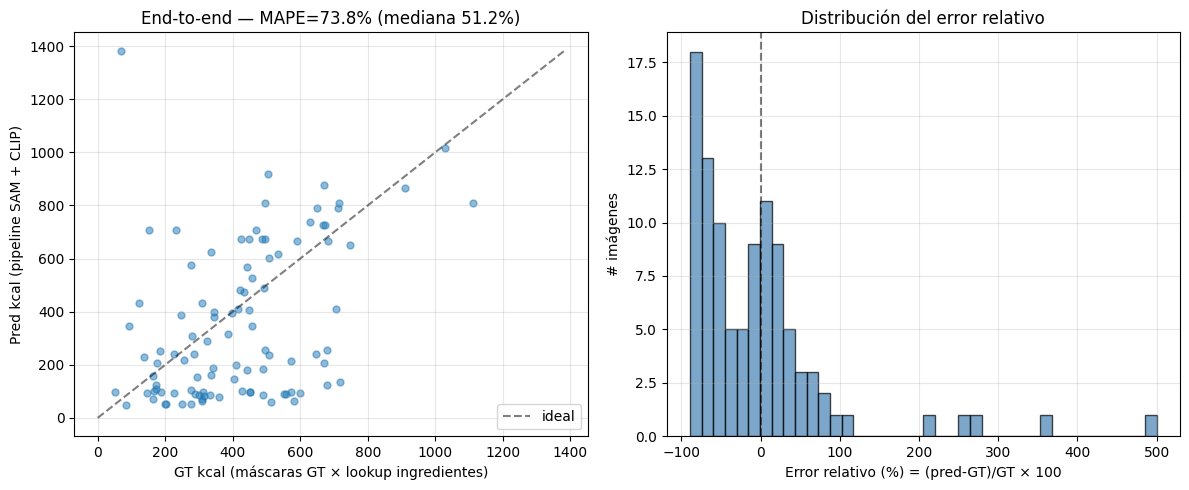

In [7]:
cal_rows = []
for idx in tqdm(seg_idxs, desc='MAPE calórico end-to-end'):   # reusamos las mismas 100 imágenes
    s = foodseg[int(idx)]
    image = s['image'].convert('RGB')
    gt = np.array(s['label'])
    if gt.ndim == 3:
        gt = gt[..., 0]

    fg_area = int((gt > 0).sum())
    if fg_area == 0:
        continue

    # GT calórico ponderado por área de cada ingrediente
    gt_kcal = 0.0
    for cls_id in np.unique(gt):
        if cls_id == 0:
            continue
        m = (gt == cls_id)
        cls_name = FOODSEG103_CLASSES[int(cls_id) - 1]
        nut = get_ingredient_nutrition(cls_name)
        if nut is None:
            continue
        portion_g = PLATE_PORTION_G * m.sum() / fg_area
        gt_kcal += nut['calories'] * portion_g / 100

    if gt_kcal <= 0:
        continue

    pred = analyze_dish_foodseg103(image)
    cal_rows.append(dict(gt=gt_kcal, pred=pred['total_kcal']))

df = pd.DataFrame(cal_rows)
mape = (np.abs(df['pred'] - df['gt']) / df['gt']).mean() * 100
median_ape = (np.abs(df['pred'] - df['gt']) / df['gt']).median() * 100
print(f'\n=== MAPE calórico end-to-end sobre {len(df)} imágenes de FoodSeg103 ===')
print(f'  MAPE (media):  {mape:.1f}%')
print(f'  MAPE (mediana): {median_ape:.1f}%  (más robusta a outliers)')
print(f'  Rango pred: [{df["pred"].min():.0f}, {df["pred"].max():.0f}] kcal')
print(f'  Rango GT:   [{df["gt"].min():.0f}, {df["gt"].max():.0f}] kcal')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(df['gt'], df['pred'], alpha=0.5, s=25)
m_max = max(df['gt'].max(), df['pred'].max())
ax[0].plot([0, m_max], [0, m_max], 'k--', alpha=0.5, label='ideal')
ax[0].set(xlabel='GT kcal (máscaras GT × lookup ingredientes)',
          ylabel='Pred kcal (pipeline SAM + CLIP)',
          title=f'End-to-end — MAPE={mape:.1f}% (mediana {median_ape:.1f}%)')
ax[0].legend(); ax[0].grid(alpha=0.3)

# Histograma de error relativo
rel_err = (df['pred'] - df['gt']) / df['gt'] * 100
ax[1].hist(rel_err.clip(-200, 500), bins=40, color='steelblue', alpha=0.7, edgecolor='black')
ax[1].axvline(0, color='k', linestyle='--', alpha=0.5)
ax[1].set(xlabel='Error relativo (%) = (pred-GT)/GT × 100',
          ylabel='# imágenes',
          title='Distribución del error relativo')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calorie_mape_foodseg103.png', dpi=110, bbox_inches='tight')
plt.show()

## 🖼️ Parte 8 — Visualización cualitativa

Seis imágenes de FoodSeg103 con tres columnas cada una:

- **(a) GT**: máscaras de ingrediente del dataset, una por color.
- **(b) SAM**: máscaras que SAM produce a partir de los prompts de YOLO (sin clasificar).
- **(c) SAM + CLIP**: máscaras SAM con la etiqueta CLIP top-1 y las kcal asignadas a cada una.

Sirve para inspeccionar a ojo: ¿donde SAM segmenta bien y CLIP etiqueta bien? ¿qué ingredientes confunde sistemáticamente?

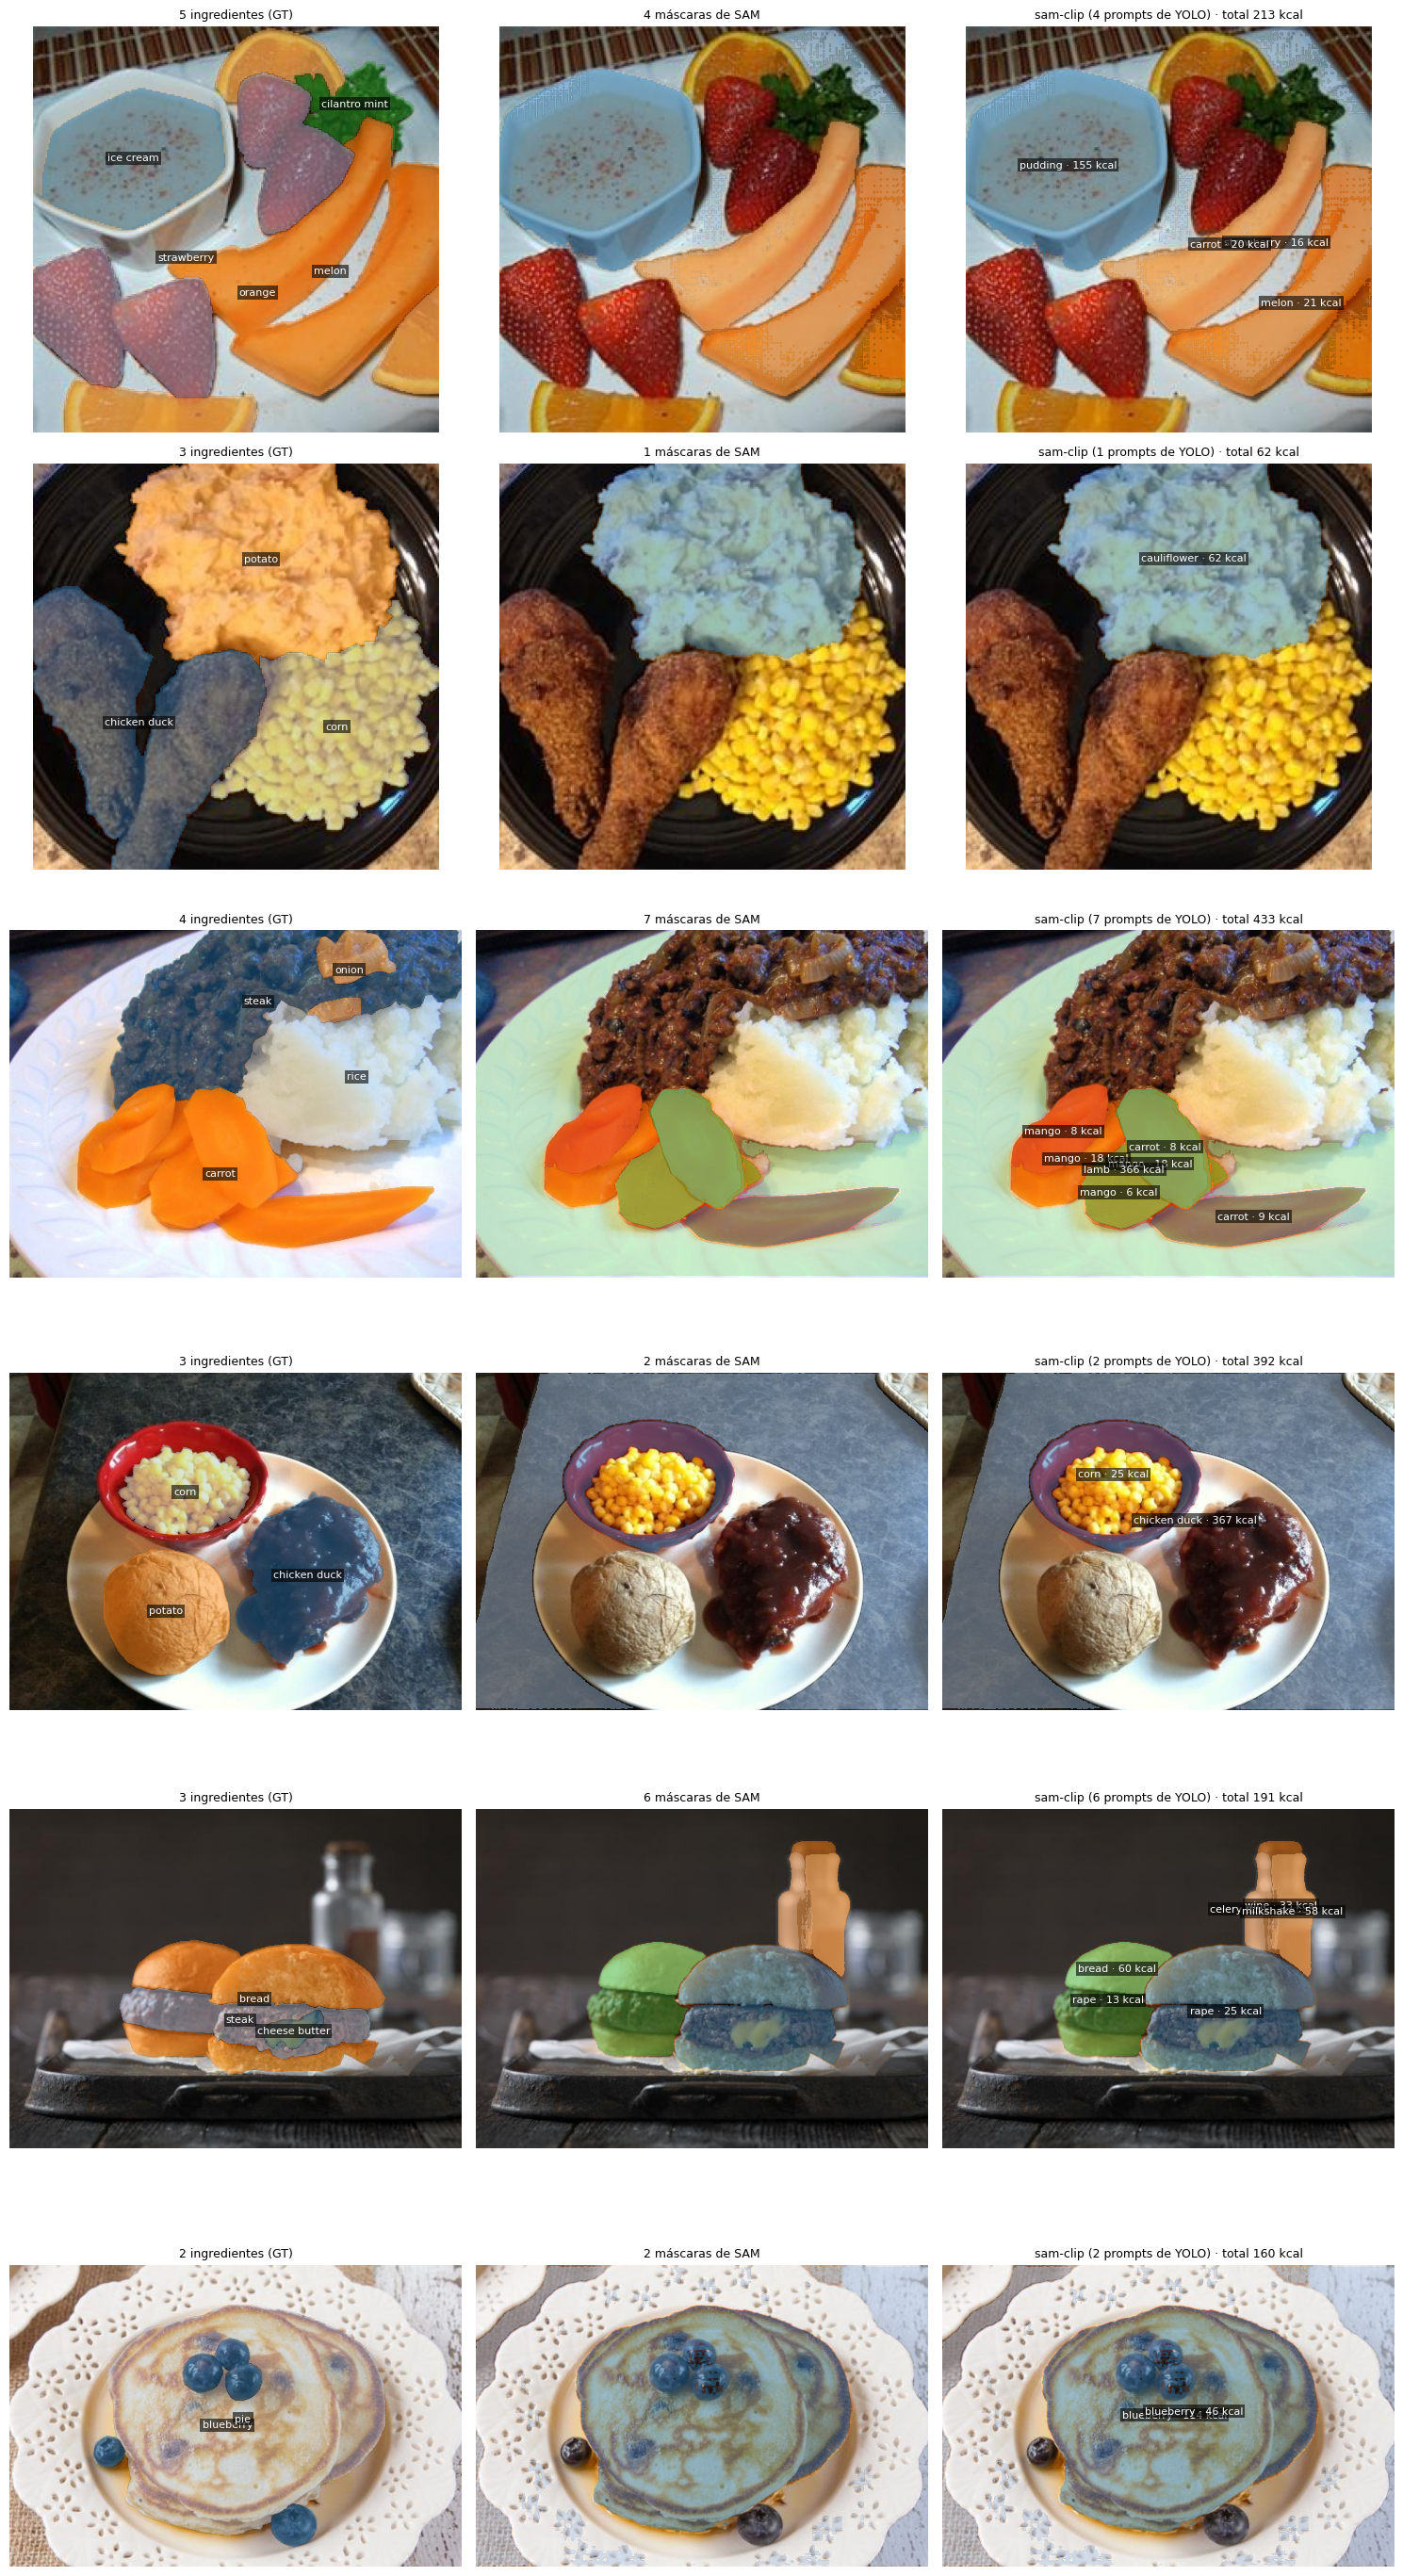

In [8]:
def overlay_masks(ax, image, masks, labels=None, alpha=0.45):
    """Pinta las máscaras una por color (tab20) y opcionalmente escribe el label en el centroide."""
    ax.imshow(image); ax.axis('off')
    colors = plt.cm.tab20.colors
    for i, m in enumerate(masks):
        color = colors[i % len(colors)]
        rgba = np.zeros((*m.shape, 4))
        rgba[m] = (*color, alpha)
        ax.imshow(rgba)
        if labels is not None:
            ys, xs = np.where(m)
            if len(xs):
                ax.text(float(xs.mean()), float(ys.mean()), labels[i],
                        fontsize=8, color='white', ha='center', va='center',
                        bbox=dict(facecolor='black', alpha=0.6, pad=1.5, edgecolor='none'))


qual_idxs = rng.choice(len(foodseg), size=6, replace=False)
fig, axes = plt.subplots(6, 3, figsize=(15, 28))
for col, header in enumerate(['(a) Máscaras GT',
                              '(b) SAM (prompts YOLO)',
                              '(c) SAM + CLIP zero-shot']):
    axes[0, col].set_title(header, fontsize=11, fontweight='bold', pad=10)

for row, idx in enumerate(qual_idxs):
    s = foodseg[int(idx)]
    image = s['image'].convert('RGB')
    gt = np.array(s['label'])
    if gt.ndim == 3: gt = gt[..., 0]
    H, W = gt.shape

    # (a) GT
    gt_masks, gt_labels = [], []
    for cls_id in np.unique(gt):
        if cls_id == 0: continue
        m = (gt == cls_id)
        if m.sum() < 0.003 * H * W: continue
        gt_masks.append(m)
        gt_labels.append(FOODSEG103_CLASSES[int(cls_id) - 1].strip())
    overlay_masks(axes[row, 0], image, gt_masks, labels=gt_labels)
    axes[row, 0].set_title(f'{len(gt_masks)} ingredientes (GT)', fontsize=9)

    # (b) SAM con prompts YOLO
    boxes = yolo_prompt_boxes(image) or [(0, 0, W, H)]
    sam_masks = segment_with_sam(image, boxes)
    overlay_masks(axes[row, 1], image, sam_masks)
    axes[row, 1].set_title(f'{len(sam_masks)} máscaras de SAM', fontsize=9)

    # (c) SAM + CLIP
    result = analyze_dish_foodseg103(image)
    pred_masks  = [d['mask'] for d in result['detections']]
    pred_labels = [f"{d['ingredient'].strip()} · {d['kcal']:.0f} kcal"
                   for d in result['detections']]
    overlay_masks(axes[row, 2], image, pred_masks, labels=pred_labels)
    axes[row, 2].set_title(f"{result['mode']} · total {result['total_kcal']:.0f} kcal", fontsize=9)

plt.tight_layout()
plt.savefig('foodseg103_qualitative.png', dpi=110, bbox_inches='tight')
plt.show()

## 📋 Resumen + limitaciones

In [9]:
print('=' * 70)
print('RESUMEN — Notebook 08: pipeline FoodSeg103 con SAM + CLIP zero-shot')
print('=' * 70)
print()
print('Arquitectura:')
print('  YOLOv8-COCO (prompts) -> SAM vit_b (máscaras) -> CLIP ViT-B/32 (zero-shot)')
print(f'  Lookup nutricional: {len(nutrition_db)}/103 ingredientes desde USDA FDC + overrides')
print()
print('Segmentación class-agnostic sobre FoodSeg103:')
print(f'  Box-as-mask (nb07):  mIoU = {np.mean(box_ious):.3f}   Dice = {np.mean(box_dices):.3f}')
print(f'  SAM (nb08):          mIoU = {np.mean(sam_ious):.3f}   Dice = {np.mean(sam_dices):.3f}')
print(f'  Mejora absoluta:     +{np.mean(sam_ious)-np.mean(box_ious):.3f} mIoU')
print()
print(f'Clasificación CLIP zero-shot sobre {total} crops oráculo:')
print(f'  Top-1: {clip_top1/total:.3f}   Top-3: {clip_top3/total:.3f}   Top-5: {clip_top5/total:.3f}')
print()
print(f'MAPE calórico end-to-end sobre {len(df)} imágenes:')
print(f'  media:   {mape:.1f}%')
print(f'  mediana: {median_ape:.1f}%')
print()
print('Limitaciones honestas:')
print('  1. CLIP zero-shot top-1 típicamente ~20-40% — confunde ingredientes')
print('     visualmente parecidos (variantes de hongos, hojas verdes, salsas).')
print('     Mitigación futura: fine-tune EfficientNet-B0 sobre crops de FoodSeg103.')
print('  2. YOLO sigue siendo cuello de botella en la detección: cuando no detecta')
print('     nada, el fallback recorta toda la imagen y SAM segmenta lo más visible.')
print('     Alternativa: usar el auto-mask-generator de SAM (más lento pero ciego al')
print('     vocabulario de COCO).')
print('  3. La porción de 250 g/plato repartida por área asume densidad uniforme.')
print('     Sobrestima ingredientes livianos (lechuga) y subestima densos (carne).')
print()
print('Próximo paso (nb09): router automático entre el pipeline Food-101 (nb07)')
print('y este pipeline FoodSeg103 según características de la escena de entrada.')
print('=' * 70)

RESUMEN — Notebook 08: pipeline FoodSeg103 con SAM + CLIP zero-shot

Arquitectura:
  YOLOv8-COCO (prompts) -> SAM vit_b (máscaras) -> CLIP ViT-B/32 (zero-shot)
  Lookup nutricional: 103/103 ingredientes desde USDA FDC + overrides

Segmentación class-agnostic sobre FoodSeg103:
  Box-as-mask (nb07):  mIoU = 0.495   Dice = 0.639
  SAM (nb08):          mIoU = 0.256   Dice = 0.353
  Mejora absoluta:     +-0.239 mIoU

Clasificación CLIP zero-shot sobre 300 crops oráculo:
  Top-1: 0.363   Top-3: 0.543   Top-5: 0.633

MAPE calórico end-to-end sobre 100 imágenes:
  media:   73.8%
  mediana: 51.2%

Limitaciones honestas:
  1. CLIP zero-shot top-1 típicamente ~20-40% — confunde ingredientes
     visualmente parecidos (variantes de hongos, hojas verdes, salsas).
     Mitigación futura: fine-tune EfficientNet-B0 sobre crops de FoodSeg103.
  2. YOLO sigue siendo cuello de botella en la detección: cuando no detecta
     nada, el fallback recorta toda la imagen y SAM segmenta lo más visible.
     Alte